In [125]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt
from plotnine import ggplot, aes, geom_line, labs, theme_minimal

In [2]:
image_size=240
batch_size=32
channels=3
epochs=30

In [3]:
dataset=tf.keras.preprocessing.image_dataset_from_directory("../Brain Tumor Data Set",shuffle=True,
                                                            batch_size=batch_size,image_size=(image_size,image_size))

Found 4514 files belonging to 2 classes.


In [4]:
class_names=dataset.class_names
class_names

['Brain Tumor', 'Healthy']

In [5]:
healthy=0
for image_batch,label_batch in dataset:
    healthy+=np.sum(label_batch.numpy())

In [6]:
print(healthy)
brain_tumor=len(dataset)*32-healthy
print(brain_tumor)

2087
2457


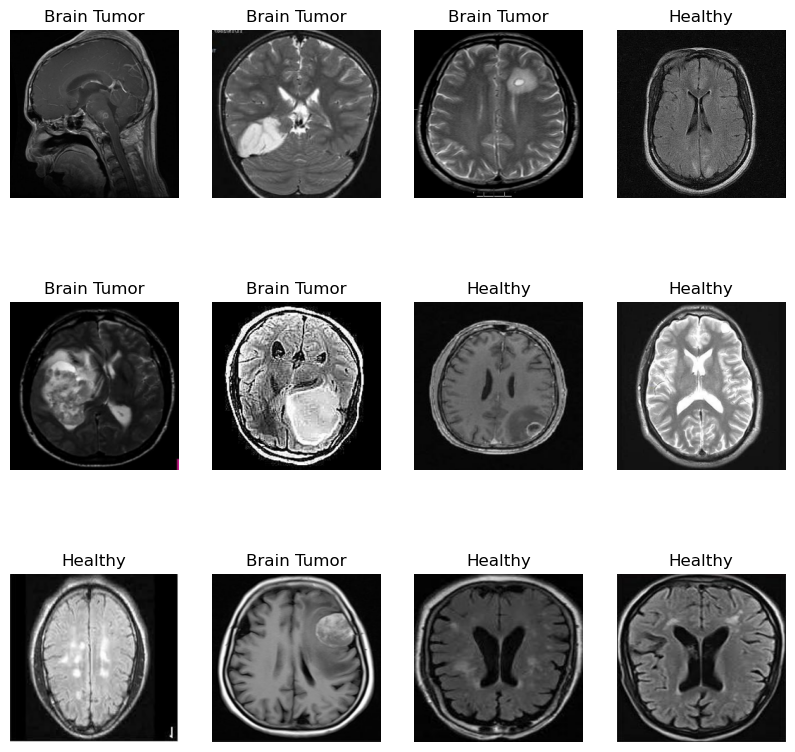

In [7]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [8]:
def get_dataset_partitions_tf(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,
                             shuffle_size=10000):
    ds_size=len(ds)
    if shuffle:
        df=ds.shuffle(shuffle_size,seed=12)
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)
    train_ds=ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    return train_ds,val_ds,test_ds
    

In [9]:
train_ds,val_ds,test_ds=get_dataset_partitions_tf(dataset)

In [10]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [11]:
resize_and_scale=tf.keras.Sequential([
    layers.Resizing(image_size,image_size),
    layers.Rescaling(1.0/255)])
    

In [14]:
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)])

In [17]:
n_classes=2
input_shape=(batch_size,image_size,image_size,channels)
model2=models.Sequential([
    resize_and_scale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation="relu",input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation="relu"),
    layers.Dense(n_classes,activation="softmax")
])
model2.build(input_shape=input_shape)

C:\Users\giorg\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 240, 240, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 240, 240, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 238, 238, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 119, 119, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 117, 117, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 58, 58, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 56, 56, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 28, 28, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 26, 26, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 13, 13, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 11, 11, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 5, 5, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 3, 3, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 1, 1, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 64)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 2)                     │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 171,394 (669.51 KB)

 Trainable params: 171,394 (669.51 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model2.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"])
stop=tf.keras.callbacks.EarlyStopping(monitor="val_loss",min_delta=1e-4,patience=4,restore_best_weights=True)
scheduler=tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=2)

In [31]:
history=model2.fit(train_ds,epochs=epochs,batch_size=batch_size,verbose=1,
          validation_data=val_ds,callbacks=[scheduler,stop])

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 54s 454ms/step - accuracy: 0.5455 - loss: 0.6836 - val_accuracy: 0.5558 - val_loss: 0.6639 - learning_rate: 0.0010
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 49s 436ms/step - accuracy: 0.6190 - loss: 0.6469 - val_accuracy: 0.6272 - val_loss: 0.6651 - learning_rate: 0.0010
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 49s 437ms/step - accuracy: 0.7006 - loss: 0.5761 - val_accuracy: 0.7656 - val_loss: 0.5006 - learning_rate: 0.0010
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 51s 449ms/step - accuracy: 0.7559 - loss: 0.5062 - val_accuracy: 0.8013 - val_loss: 0.4340 - learning_rate: 0.0010
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 50s 442ms/step - accuracy: 0.7760 - loss: 0.4593 - val_accuracy: 0.8058 - val_loss: 0.4182 - learning_rate: 0.0010
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 50s 444ms/step - accuracy: 0.8062 - loss: 0.4140 - val_accuracy: 0.8482 - val_loss: 0.3904 - learning_rate: 0.0010
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 49s 434ms/step - accuracy: 0.8

In [33]:
model2.evaluate(test_ds)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.9506 - loss: 0.1742


[0.16548603773117065, 0.9577777981758118]

In [35]:
history.params

{'verbose': 1, 'epochs': 30, 'steps': 113}

In [37]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

In [39]:
d={}
for key in history.history.keys():
    d["{}".format(key)]=history.history["{}".format(key)]
print(d)
    

{'accuracy': [0.564712405204773, 0.6548672318458557, 0.7046459913253784, 0.7555309534072876, 0.778761088848114, 0.8083517551422119, 0.8387721180915833, 0.8611725568771362, 0.8766592741012573, 0.8910398483276367, 0.908462405204773, 0.9358407258987427, 0.9292035102844238, 0.9358407258987427, 0.9521570801734924, 0.9521570801734924, 0.9540929198265076, 0.9585176706314087, 0.9593473672866821, 0.9681969285011292, 0.9640486836433411, 0.9681969285011292, 0.9690265655517578, 0.9720686078071594, 0.9670907258987427, 0.9737278819084167, 0.9673672318458557], 'loss': [0.6791248321533203, 0.6184390187263489, 0.5649718642234802, 0.4969671666622162, 0.45837393403053284, 0.4127238392829895, 0.3582448959350586, 0.3295321762561798, 0.2891257703304291, 0.26011309027671814, 0.2284282147884369, 0.1871912181377411, 0.18642958998680115, 0.1699366718530655, 0.14644648134708405, 0.1334107369184494, 0.12832778692245483, 0.11566861718893051, 0.11287112534046173, 0.09970682114362717, 0.1055058017373085, 0.092395611

In [45]:
df=pd.DataFrame(data=d)
df["epoch"]=range(1,28)
df

,accuracy,loss,val_accuracy,val_loss,learning_rate,epoch
0,0.564712,0.679125,0.555804,0.663872,0.001000,1
1,0.654867,0.618439,0.627232,0.665134,0.001000,2
2,0.704646,0.564972,0.765625,0.500638,0.001000,3
3,0.755531,0.496967,0.801339,0.434008,0.001000,4
4,0.778761,0.458374,0.805804,0.418150,0.001000,5
5,0.808352,0.412724,0.848214,0.390444,0.001000,6
6,0.838772,0.358245,0.770089,0.520576,0.001000,7
7,0.861173,0.329532,0.892857,0.270532,0.001000,8
8,0.876659,0.289126,0.872768,0.323297,0.001000,9
9,0.891040,0.260113,0.868304,0.300537,0.001000,10


In [85]:
df_long_metric = df.melt(id_vars='epoch', 
                  value_vars=['accuracy', 'val_accuracy'],
                  var_name='metric', 
                  value_name='value')

In [89]:
df_long_metric

,epoch,metric,value
0,1,accuracy,0.564712
1,2,accuracy,0.654867
2,3,accuracy,0.704646
3,4,accuracy,0.755531
4,5,accuracy,0.778761
5,6,accuracy,0.808352
6,7,accuracy,0.838772
7,8,accuracy,0.861173
8,9,accuracy,0.876659
9,10,accuracy,0.891040


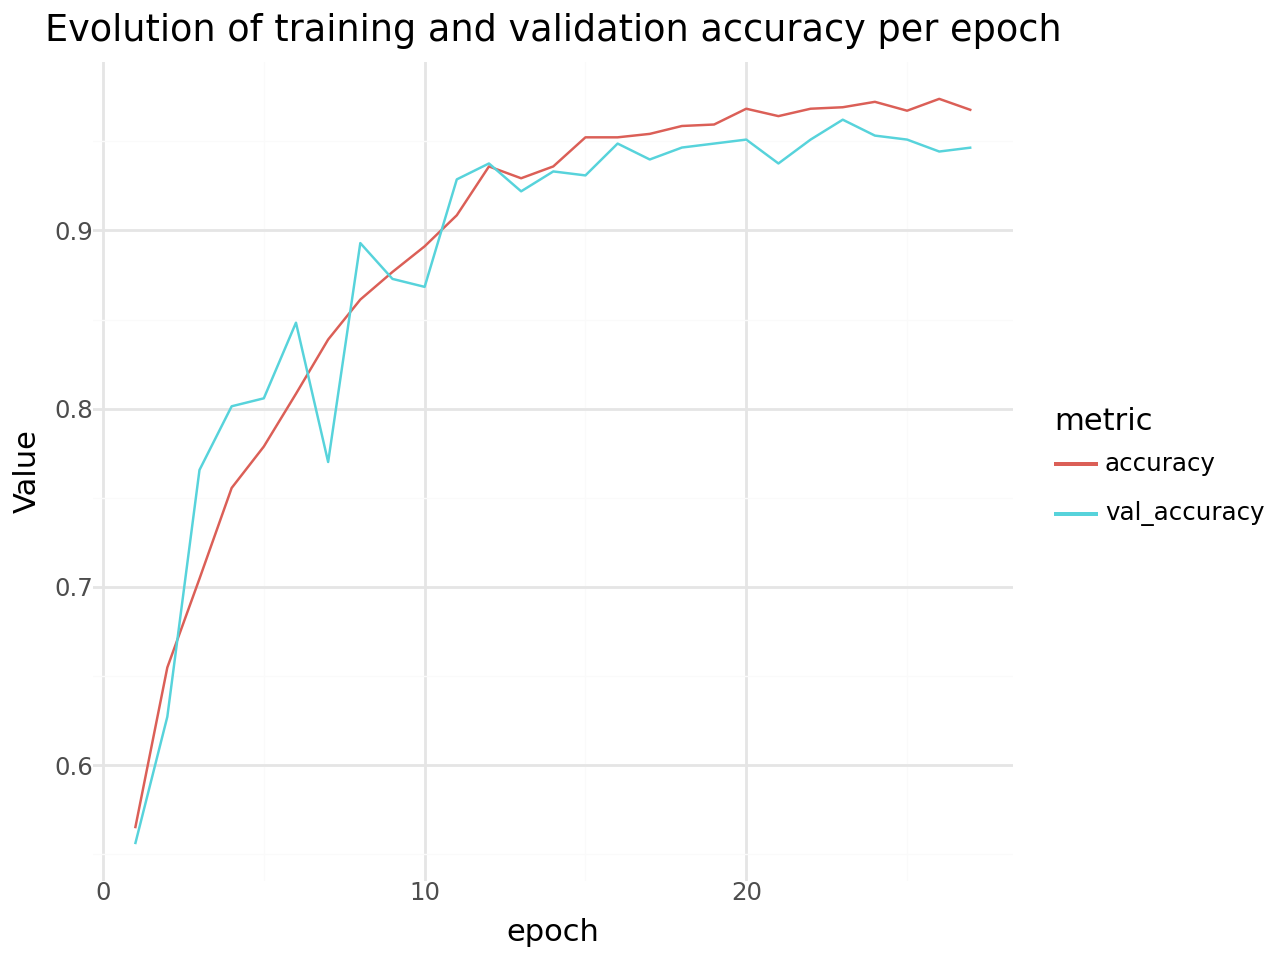

In [103]:
plot = (
    ggplot(df_long_metric, aes(x='epoch', y='value', color='metric')) +
    geom_line() +
    labs(title='Evolution of training and validation accuracy per epoch', x='epoch', y='Value') +
    theme_minimal()
)
plot

In [105]:
df_long_loss=df.melt(id_vars='epoch', 
                  value_vars=['loss', 'val_loss'],
                  var_name='metric', 
                  value_name='value')

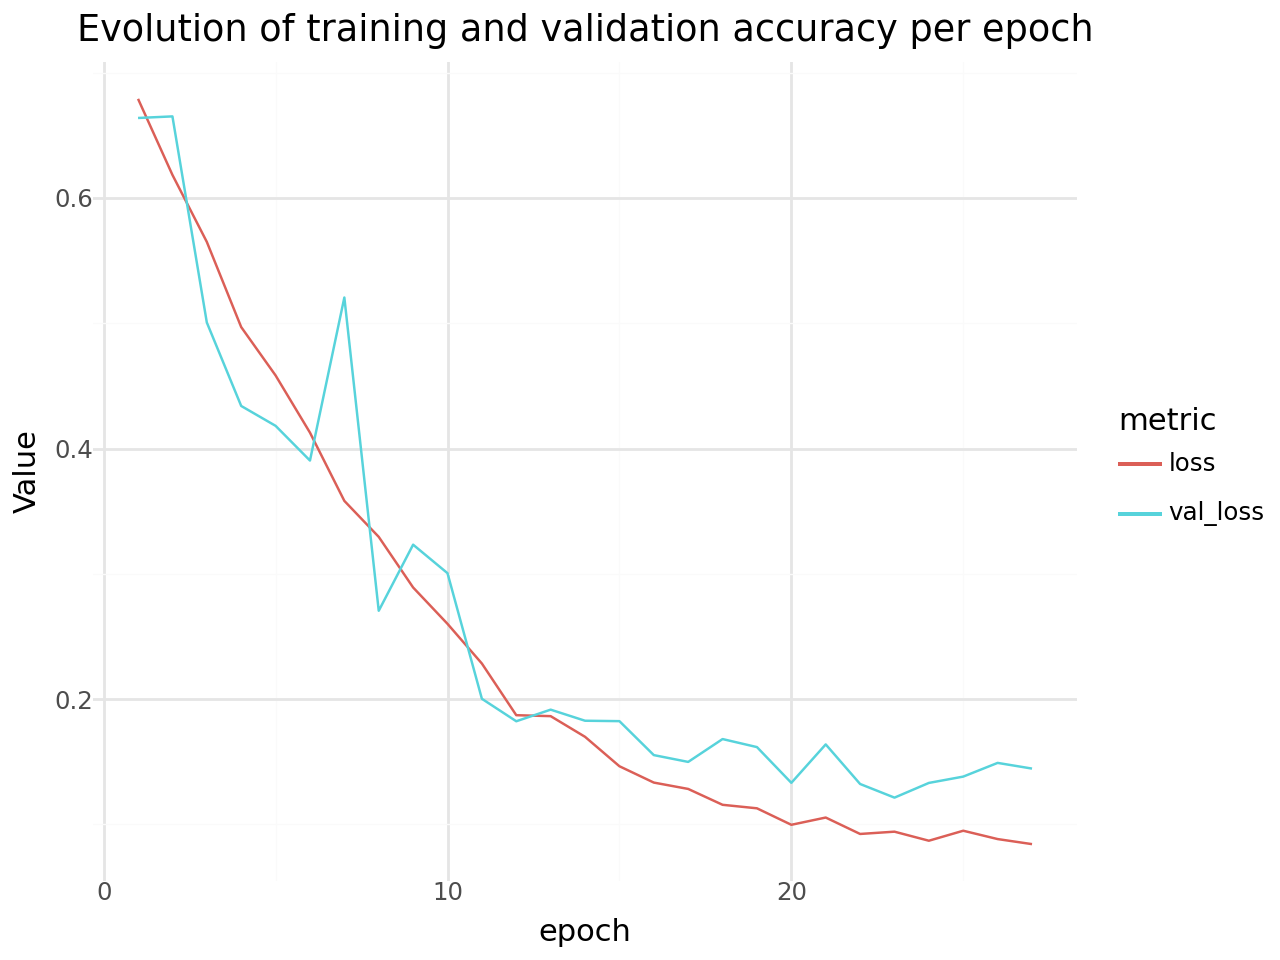

In [107]:
plot = (
    ggplot(df_long_loss, aes(x='epoch', y='value', color='metric')) +
    geom_line() +
    labs(title='Evolution of training and validation accuracy per epoch', x='epoch', y='Value') +
    theme_minimal()
)
plot

First image to predict
Actual label: Brain Tumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Predicted label: Brain Tumor


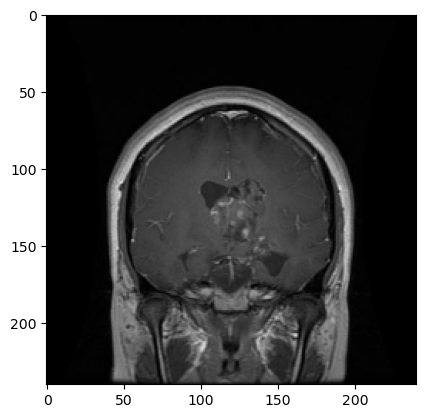

In [111]:
for images_batch,labels_batch in test_ds.take(1):
    first_image=images_batch[0].numpy().astype("uint8")
    first_label=labels_batch[0].numpy()
    print("First image to predict")
    plt.imshow(first_image)
    print("Actual label:",class_names[first_label])
    batch_prediction=model2.predict(images_batch)
    print("Predicted label:",class_names[np.argmax(batch_prediction[0])])

In [121]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0) # Create a batch
    predictions=model.predict(img_array)
    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*(np.max(predictions[0])),2)
    return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


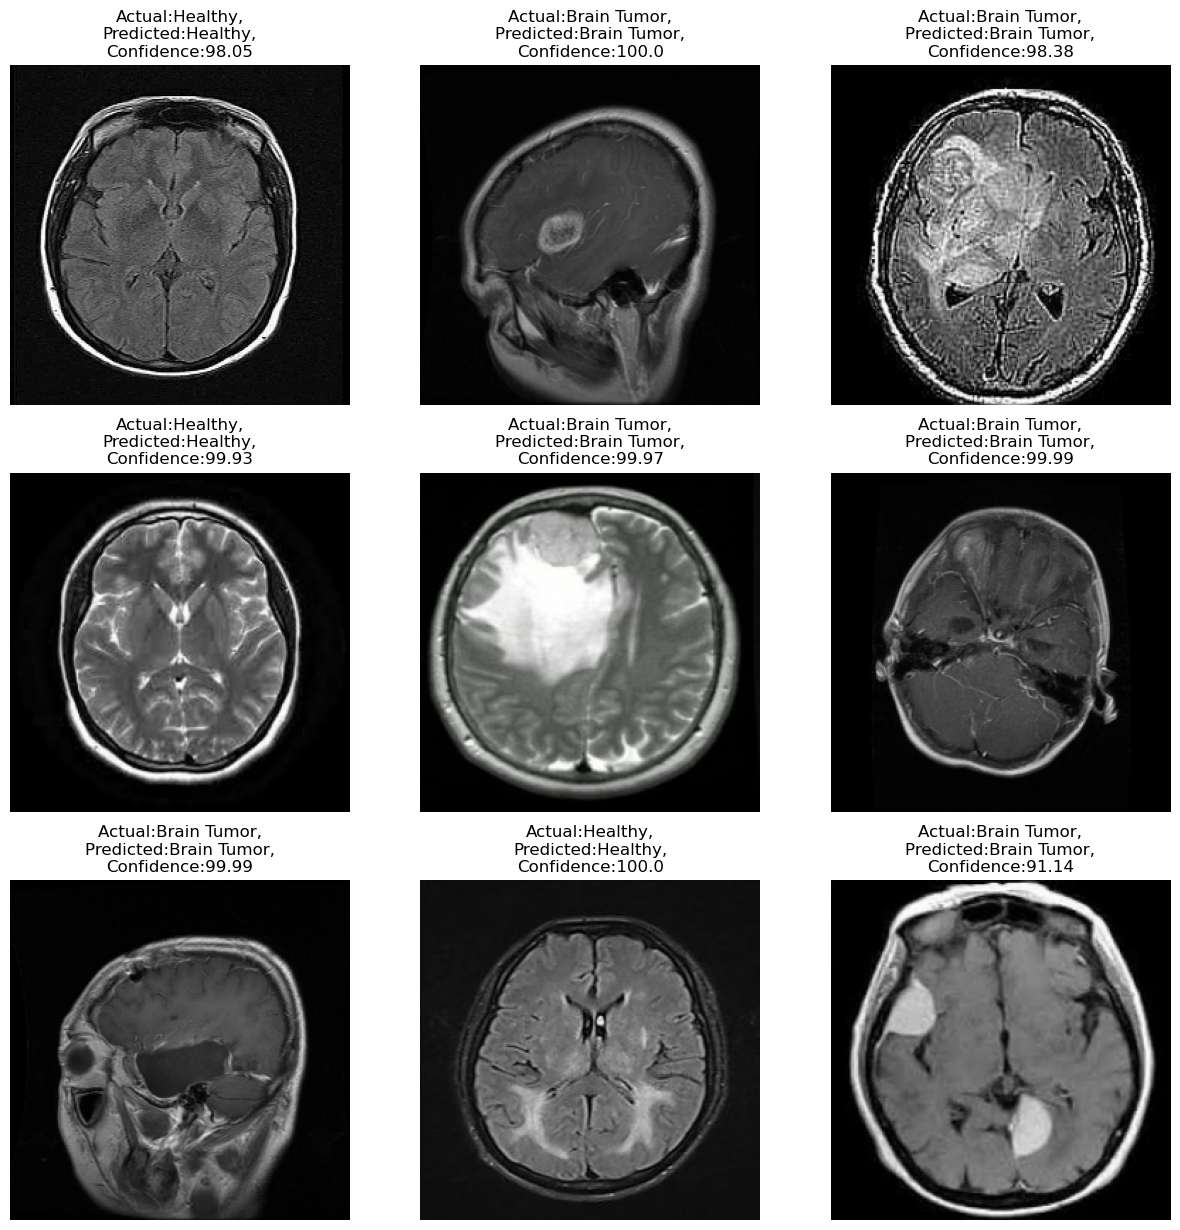

In [123]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class,confidence=predict(model2,images[i].numpy())
        actual_class=class_names[labels[i]]
        plt.title("Actual:{},\nPredicted:{},\nConfidence:{}".format(actual_class,predicted_class,confidence))
        plt.axis("off")